In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
#import dataset
intax_sales = pd.read_csv('/content/drive/MyDrive/raw_data/sales_after_2025.csv')

In [49]:
#read dataset
intax_sales.head()
intax_sales.shape
intax_sales.info()
intax_sales.describe()
intax_sales.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10249 entries, 0 to 10248
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   tanggal          10249 non-null  object
 1   tahun            10249 non-null  int64 
 2   bulan            10249 non-null  int64 
 3   hari             10249 non-null  object
 4   kategori         10249 non-null  object
 5   nama_produk      10249 non-null  object
 6   lokasi_toko      10249 non-null  object
 7   metode_bayar     10249 non-null  object
 8   harga_satuan     10249 non-null  int64 
 9   qty              10249 non-null  int64 
 10  diskon_idr       10249 non-null  int64 
 11  total_penjualan  10249 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 961.0+ KB


,0
tanggal,0
tahun,0
bulan,0
hari,0
kategori,0
nama_produk,0
lokasi_toko,0
metode_bayar,0
harga_satuan,0
qty,0


In [50]:
#changing date time
intax_sales['tanggal'] = pd.to_datetime(intax_sales['tanggal'])
intax_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10249 entries, 0 to 10248
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   tanggal          10249 non-null  datetime64[ns]
 1   tahun            10249 non-null  int64         
 2   bulan            10249 non-null  int64         
 3   hari             10249 non-null  object        
 4   kategori         10249 non-null  object        
 5   nama_produk      10249 non-null  object        
 6   lokasi_toko      10249 non-null  object        
 7   metode_bayar     10249 non-null  object        
 8   harga_satuan     10249 non-null  int64         
 9   qty              10249 non-null  int64         
 10  diskon_idr       10249 non-null  int64         
 11  total_penjualan  10249 non-null  int64         
dtypes: datetime64[ns](1), int64(6), object(5)
memory usage: 961.0+ KB


In [51]:
#change columns name
intax_sales.reset_index()
intax_sales.columns = ['date', 'year', 'month', 'day', 'category', 'product_name', 'sales_channel',
                       'payment_method', 'base_price', 'quantity', 'discount_idr', 'revenue'
]
intax_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10249 entries, 0 to 10248
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            10249 non-null  datetime64[ns]
 1   year            10249 non-null  int64         
 2   month           10249 non-null  int64         
 3   day             10249 non-null  object        
 4   category        10249 non-null  object        
 5   product_name    10249 non-null  object        
 6   sales_channel   10249 non-null  object        
 7   payment_method  10249 non-null  object        
 8   base_price      10249 non-null  int64         
 9   quantity        10249 non-null  int64         
 10  discount_idr    10249 non-null  int64         
 11  revenue         10249 non-null  int64         
dtypes: datetime64[ns](1), int64(6), object(5)
memory usage: 961.0+ KB


In [52]:
#EDA : Calculating revenue
#---full_year_comparison (2023 vs 2024)
data_2023_2024 = intax_sales[intax_sales['year']<2025]
revenue_2023_2024 = data_2023_2024.groupby('year')['revenue'].sum()
revenue_year = revenue_2023_2024.reset_index()
revenue_year.columns = ['year', 'total_revenue']
print(revenue_year)

#---growth over year
growth = revenue_year['total_revenue'].pct_change()*100
print(growth)
print(str('Growth_2023_2024')+': '+'~24%')

#---YTD (Jan - Mei)
jan_mei = intax_sales[intax_sales['month'] <=5]
revenue_ytd = jan_mei.groupby('year')['revenue'].sum()
print(revenue_ytd)

ytd_growth = revenue_ytd.pct_change()*100
ytd_growth

   year  total_revenue
0  2023     1993630250
1  2024     2478317500
0          NaN
1    24.311793
Name: total_revenue, dtype: float64
Growth_2023_2024: ~24%
year
2023    752646750
2024    961757500
2025    846548000
Name: revenue, dtype: int64


,revenue
year,
2023,NaN
2024,27.783386
2025,-11.979059


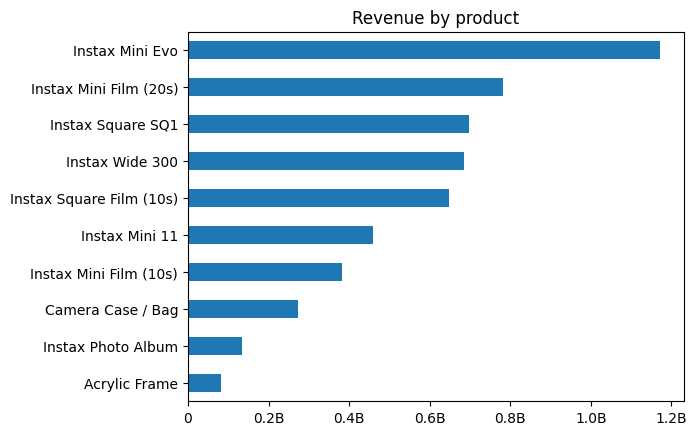

In [53]:
#EDA: Product Analysis

#---revenue vs product
product_revenue = intax_sales.groupby('product_name')['revenue'].sum().sort_values(ascending=True)
product_revenue.plot(kind = 'barh')
plt.title('Revenue by product')
plt.xlabel('')
plt.xticks([0, 0.2e9, 0.4e9, 0.6e9, 0.8e9, 1e9, 1.2e9],
           ['0', '0.2B', '0.4B', '0.6B', '0.8B', '1.0B', '1.2B'])

plt.ylabel('')
plt.show()

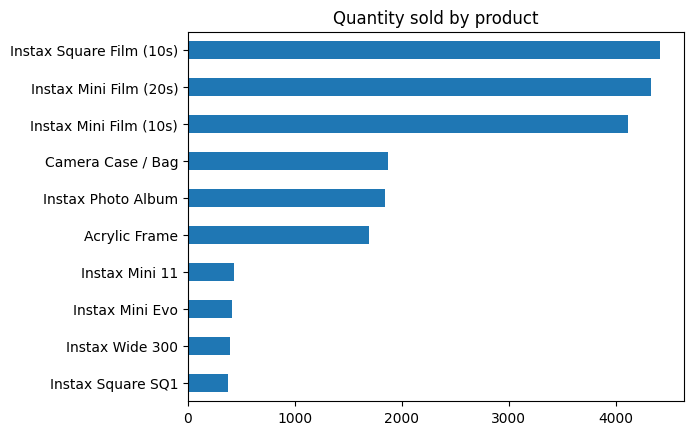

In [54]:
#---quantity_sold vs product
product_quantity = intax_sales.groupby('product_name')['quantity'].sum().sort_values(ascending=True)
product_quantity.plot(kind = 'barh')
plt.title('Quantity sold by product')
plt.ylabel('')
plt.xlabel('')
plt.show()

In [55]:
#EDA: Discount impact analysis : Is discount make people buy more our products?
#discount_summary
discount = intax_sales.groupby('discount_idr').agg(
    {'revenue' : 'sum',
     'quantity' : 'sum',
     'discount_idr' : 'count'
     }
).rename(columns={'revenue' : 'total_revenue',
                  'discount_idr' : 'num_of_transactions'}).reset_index()
discount['dicount_status'] = discount['discount_idr'].apply(
    lambda x: 'No Discount' if x == 0 else 'Discount'
)
discount.head(
)

discount_summary = discount.groupby('dicount_status').agg(
    {
        'total_revenue' : 'sum',
        'quantity' : 'sum',
        'num_of_transactions' : 'sum'
    }
).reset_index()
discount_summary.columns = ['discount_status', 'total_revenue', 'total_units_sold', 'num_of_transactions']
discount_summary['avg_revenue_per_transaction'] = discount_summary['total_revenue']/discount_summary['num_of_transactions']
discount_summary['avg_units_sold_per_transaction'] = discount_summary['total_units_sold']/discount_summary['num_of_transactions']
discount_summary['revenue_per_item'] = discount_summary['total_revenue']/discount_summary['total_units_sold']
print(discount_summary)

print('No much different between with or no discount')

  discount_status  total_revenue  total_units_sold  num_of_transactions  \
0        Discount     1428590750              5467                 2849   
1     No Discount     3889905000             14403                 7400   

   avg_revenue_per_transaction  avg_units_sold_per_transaction  \
0                501435.854686                        1.918919   
1                525662.837838                        1.946351   

   revenue_per_item  
0     261311.642583  
1     270076.025828  
No much different between with or no discount


In [56]:
#EDA: Discount Impact Analysis

#product_summary
product_summary = intax_sales.groupby('product_name').agg(
    {
        'quantity': 'sum',
        'discount_idr': 'sum',
        'revenue': 'sum',
        'product_name': 'count'
    }
).rename(columns={'product_name' : 'num_of_transactions'}).reset_index()
product_summary.columns = ['product_name', 'quantity', 'discount', 'revenue', 'num_of_transactions']
product_summary.head()

,product_name,quantity,discount,revenue,num_of_transactions
0,Acrylic Frame,1695,1560000,83190000,820
1,Camera Case / Bag,1869,6060000,274290000,859
2,Instax Mini 11,426,8910000,459690000,408
3,Instax Mini Evo,414,28130000,1172470000,397
4,Instax Mini Film (10s),4113,8274500,382460500,1966


In [57]:
#EDA : Discount impact analysis (is any product on 'discount redflag?')

product_summary['avg_discount_per_item'] = product_summary['discount']/product_summary['quantity']
product_summary_sorted = product_summary.sort_values('avg_discount_per_item', ascending = False)
product_summary_sorted

#discount_revenue_threshold
high_discount = product_summary['avg_discount_per_item'].quantile(0.75)
low_revenue = product_summary['revenue'].quantile(0.25)
print(str('high_discount')+': '+ str(high_discount))
print(str('low_revenue')+': '+ str(low_revenue))
product_summary_sorted

def discount_flag(row):
    if row['avg_discount_per_item'] >= high_discount and row['revenue'] <= low_revenue:
        return 'High Discount - Low Revenue'
    elif row['avg_discount_per_item'] >= high_discount:
        return 'High Discount'
    elif row['revenue'] <= low_revenue:
        return 'Low Revenue'
    else:
        return 'Normal'

product_summary['discount_flag'] = product_summary.apply(discount_flag, axis=1)
print(product_summary.sort_values('discount_flag'))
print('No product on High Discount - Low Revenue')

high_discount: 31137.964148527528
low_revenue: 301332625.0
               product_name  quantity  discount     revenue  \
3           Instax Mini Evo       414  28130000  1172470000   
8         Instax Square SQ1       374  12920000   697680000   
9           Instax Wide 300       391  19710000   684090000   
0             Acrylic Frame      1695   1560000    83190000   
1         Camera Case / Bag      1869   6060000   274290000   
6        Instax Photo Album      1839   3060000   134865000   
2            Instax Mini 11       426   8910000   459690000   
4    Instax Mini Film (10s)      4113   8274500   382460500   
5    Instax Mini Film (20s)      4332  19119750   782300250   
7  Instax Square Film (10s)      4417  15090000   647460000   

   num_of_transactions  avg_discount_per_item  discount_flag  
3                  397           67946.859903  High Discount  
8                  355           34545.454545  High Discount  
9                  378           50409.207161  High Discou

In [58]:
#EDA: Payment methods analysis
intax_sales.head()

payment_sales = intax_sales.groupby('payment_method').agg(
    {
        'revenue' : 'sum',
        'quantity' : 'sum',
        'payment_method' : 'count'
    }
).rename(columns={'payment_method' : 'num_of_transactions'}).reset_index()
payment_sales['avg_revenue_per_transaction'] = payment_sales['revenue']/payment_sales['num_of_transactions']
payment_sales

,payment_method,revenue,quantity,num_of_transactions,avg_revenue_per_transaction
0,E-Wallet (Gopay/OVO),1270414250,4922,2505,507151.397206
1,Kartu Kredit,1354056750,4929,2551,530794.492356
2,Paylater,1335105250,4859,2551,523365.444924
3,Transfer Bank,1358919500,5160,2642,514352.573808


In [59]:
#EDA : sales channel perfomance
intax_sales.head()
sales_perfomance = intax_sales.groupby('sales_channel').agg(
    {
        'quantity' : 'sum',
        'revenue' : 'sum'
    }
).reset_index()
sales_perfomance['avg_revenue_per_quantity'] = sales_perfomance['revenue']/sales_perfomance['quantity']
print(sales_perfomance.sort_values('avg_revenue_per_quantity', ascending = False))
print('Website has highest value customers than others')

            sales_channel  quantity     revenue  avg_revenue_per_quantity
4                 Website      3968  1151522750             290202.305948
3      Tokopedia Official      4053  1108410250             273478.966198
1             Shopee Mall      3878  1016882000             262218.153687
2         Surabaya Branch      3989  1031279250             258530.772123
0  Jakarta Official Store      3982  1010401500             253742.214967
Website has highest value customers than others


In [60]:
#EDA: Time behavior analysis
time_behavior = intax_sales[['month', 'day', 'revenue']]
month_revenue = time_behavior.groupby('month')['revenue'].sum().sort_values(ascending = False)
print(month_revenue.head(5))

day_revenue = time_behavior.groupby('day')['revenue'].sum().sort_values(ascending = False)
print(day_revenue.head(5))

month
1     818427250
12    792880000
3     511916250
4     446970500
2     440057750
Name: revenue, dtype: int64
day
Sunday       974750000
Saturday     894811250
Friday       894497500
Monday       684374750
Wednesday    643975500
Name: revenue, dtype: int64


In [61]:
#EDA: AOV by month and sales channel

sales_month = intax_sales.groupby('month').agg(
    {
        'revenue' : 'sum',
        'date' : 'count'
    }
).rename(columns={'date' : 'num_of_transactions'}).reset_index()
sales_month['AOV_by_month']= sales_month['revenue']/sales_month['num_of_transactions']
print(sales_month.sort_values('AOV_by_month', ascending = False))

sales_by_channel = intax_sales.groupby('sales_channel').agg(
    {
        'revenue' : 'sum',
        'date' : 'count'
    }
).rename(columns={'date' : 'num_of_transactions'}).reset_index()

sales_by_channel['AOV_by_channel']= sales_by_channel['revenue']/sales_by_channel['num_of_transactions']
print(sales_by_channel.sort_values('AOV_by_channel', ascending = False))

    month    revenue  num_of_transactions   AOV_by_month
1       2  440057750                  782  562733.695652
10     11  331625000                  609  544540.229885
2       3  511916250                  944  542284.163136
5       6  279781000                  518  540117.760618
6       7  329128250                  613  536913.947798
4       5  343580500                  643  534339.813375
7       8  415601250                  785  529428.343949
8       9  308470500                  591  521946.700508
3       4  446970500                  858  520944.638695
0       1  818427250                 1602  510878.433208
9      10  300057500                  617  486316.855754
11     12  792880000                 1687  469994.072318
            sales_channel     revenue  num_of_transactions  AOV_by_channel
4                 Website  1151522750                 2060   558991.626214
3      Tokopedia Official  1108410250                 2086   531356.783317
1             Shopee Mall  1016882